In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons, make_circles

torch.manual_seed(0)
np.random.seed(0)

In [3]:
np.linspace(-3, 3, 400)

array([-3.        , -2.98496241, -2.96992481, -2.95488722, -2.93984962,
       -2.92481203, -2.90977444, -2.89473684, -2.87969925, -2.86466165,
       -2.84962406, -2.83458647, -2.81954887, -2.80451128, -2.78947368,
       -2.77443609, -2.7593985 , -2.7443609 , -2.72932331, -2.71428571,
       -2.69924812, -2.68421053, -2.66917293, -2.65413534, -2.63909774,
       -2.62406015, -2.60902256, -2.59398496, -2.57894737, -2.56390977,
       -2.54887218, -2.53383459, -2.51879699, -2.5037594 , -2.4887218 ,
       -2.47368421, -2.45864662, -2.44360902, -2.42857143, -2.41353383,
       -2.39849624, -2.38345865, -2.36842105, -2.35338346, -2.33834586,
       -2.32330827, -2.30827068, -2.29323308, -2.27819549, -2.26315789,
       -2.2481203 , -2.23308271, -2.21804511, -2.20300752, -2.18796992,
       -2.17293233, -2.15789474, -2.14285714, -2.12781955, -2.11278195,
       -2.09774436, -2.08270677, -2.06766917, -2.05263158, -2.03759398,
       -2.02255639, -2.0075188 , -1.9924812 , -1.97744361, -1.96

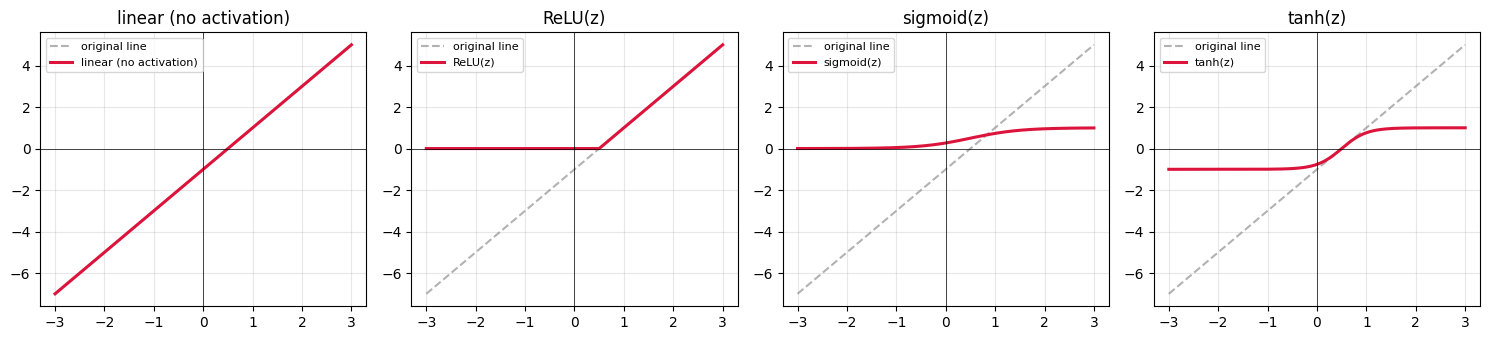

In [2]:
x = np.linspace(-3, 3, 400)
z = 2 * x - 1                              # the "line" a neuron computes

activations = {
    "linear (no activation)": z,
    "ReLU(z)":    np.maximum(0, z),
    "sigmoid(z)": 1 / (1 + np.exp(-z)),
    "tanh(z)":    np.tanh(z),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, z, '--', color='gray', alpha=0.6, label='original line')
    ax.plot(x, y, color='crimson', linewidth=2.2, label=name)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

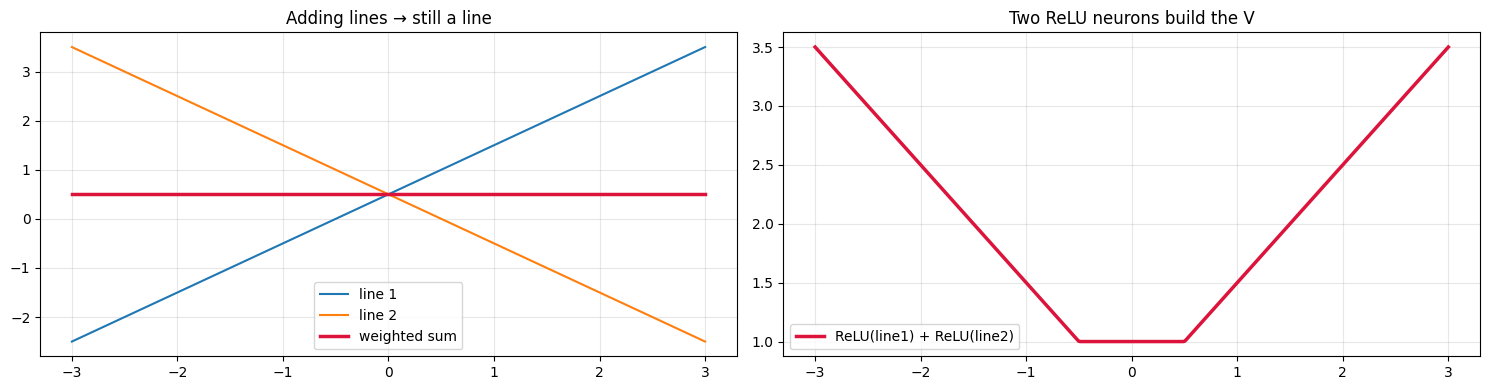

In [4]:
x = np.linspace(-3, 3, 400)
line1 =  1.0 * x + 0.5
line2 = -1.0 * x + 0.5

weighted_sum = 0.5 * line1 + 0.5 * line2   # what a neural net layer can do
via_relu     = np.maximum(0, line1) + np.maximum(0, line2)  # two ReLU neurons!

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x, line1, label='line 1'); axes[0].plot(x, line2, label='line 2')
axes[0].plot(x, weighted_sum, color='crimson', linewidth=2.5, label='weighted sum')
axes[0].set_title("Adding lines → still a line"); axes[0].legend(); axes[0].grid(alpha=0.3)


axes[1].plot(x, via_relu, color='crimson', linewidth=2.5, label='ReLU(line1) + ReLU(line2)')
axes[1].set_title("Two ReLU neurons build the V"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

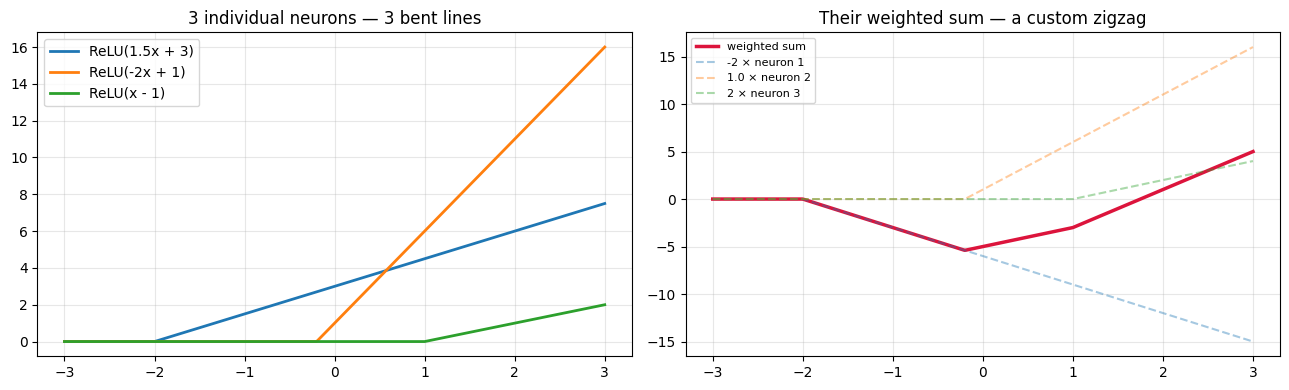

In [6]:
x = np.linspace(-3, 3, 400)

# Three ReLU neurons, each with its own (w, b). Each bends at a different place.
n1 = np.maximum(0,  1.5 * x + 3.0)     # bends at x = -2,  slope +1.5
n2 = np.maximum(0, 5.0 * x + 1.0)     # bends at x = 0.5, slope -2.0 (flips direction)
n3 = np.maximum(0,  1.0 * x - 1.0)     # bends at x = 1,   slope +1.0

# Output-layer weights — how much of each bent line we mix in
#v1, v2, v3 = 1.0, 1.0, -1.5
v1 = -2; v2 = 1.0; v3 = 2
combined = v1 * n1 + v2 * n2 + v3 * n3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LEFT: each neuron's individual bent line
axes[0].plot(x, n1, label='ReLU(1.5x + 3)',  linewidth=2)
axes[0].plot(x, n2, label='ReLU(-2x + 1)',   linewidth=2)
axes[0].plot(x, n3, label='ReLU(x - 1)',     linewidth=2)
axes[0].set_title("3 individual neurons — 3 bent lines")
axes[0].grid(alpha=0.3); axes[0].legend()

# RIGHT: the weighted sum
axes[1].plot(x, combined, color='crimson', linewidth=2.5, label='weighted sum')
axes[1].plot(x, n1 * v1, '--', alpha=0.4, label=f'{v1} × neuron 1')
axes[1].plot(x, n2 * v2, '--', alpha=0.4, label=f'{v2} × neuron 2')
axes[1].plot(x, n3 * v3, '--', alpha=0.4, label=f'{v3} × neuron 3')
axes[1].set_title("Their weighted sum — a custom zigzag")
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

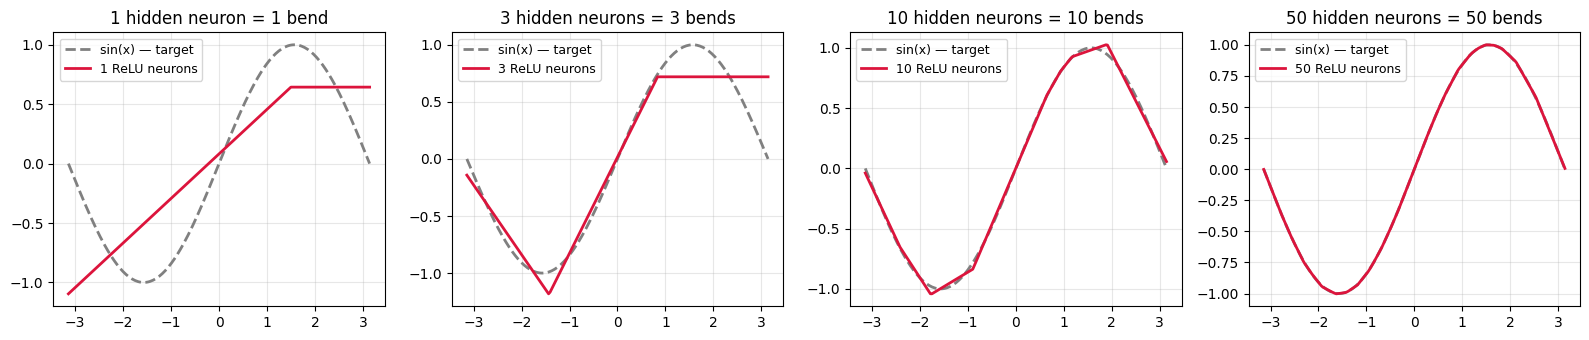

In [5]:
# Target: sin(x) on [-pi, pi]
x_data = torch.linspace(-np.pi, np.pi, 200).unsqueeze(1)
y_data = torch.sin(x_data)

def fit_sin_with_n_neurons(n_hidden, steps=3000):
    torch.manual_seed(3)
    model = nn.Sequential(
        nn.Linear(1, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 1),
    )
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(x_data) - y_data) ** 2).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x_data).squeeze().numpy()
        
        # print weights for each neuron in the 3-neuron example
    #print("Neuron 1 weights:", model[0].weight[0].item(), model[0].bias[0].item())
    #print("Neuron 2 weights:", model[0].weight[1].item(), model[0].bias[1].item())
    #print("Neuron 3 weights:", model[0].weight[2].item(), model[0].bias[2].item())

# Fit with 1, 3, 10, 50 hidden neurons
widths = [1, 3, 10, 50]
predictions = {n: fit_sin_with_n_neurons(n) for n in widths}


fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, n in zip(axes, widths):
    ax.plot(x_data.squeeze(), y_data.squeeze(), '--', color='gray',
            linewidth=2, label='sin(x) — target')
    ax.plot(x_data.squeeze(), predictions[n], color='crimson',
            linewidth=2, label=f'{n} ReLU neurons')
    ax.set_title(f"{n} hidden neuron{'s' if n > 1 else ''} = {n} bend{'s' if n > 1 else ''}")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Framework - Tensorflow

In [8]:
# If needed (Colab):
# !pip -q install tensorflow scikit-learn matplotlib tqdm

import os, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

In [9]:
# Device info
print('Physical GPUs:', tf.config.list_physical_devices('GPU'))
print('Physical CPUs:', tf.config.list_physical_devices('CPU'))

Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [10]:
# MNIST
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Load MNIST from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()



print('Raw train:', x_train.shape, y_train.shape, x_train.dtype)
print('Raw test :', x_test.shape,  y_test.shape,  x_test.dtype)


# Preprocess: float32, normalize [0,255] -> [0,1] -> [-1,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = (x_train - 0.5) / 0.5
x_test  = (x_test  - 0.5) / 0.5

#(x - mean) / std


# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

# Build tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(x_train), seed=42, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)



Raw train: (60000, 28, 28) (60000,) uint8
Raw test : (10000, 28, 28) (10000,) uint8


2026-04-25 22:00:22.596267: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-04-25 22:00:22.596327: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-04-25 22:00:22.596331: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
I0000 00:00:1777134622.596761   86152 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777134622.596970   86152 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Batch images: (64, 28, 28, 1) | labels: [4, 4, 1, 6, 2, 2, 5, 3, 2, 0, 1, 5]
Pixel range (after normalize): -1.0 to 1.0


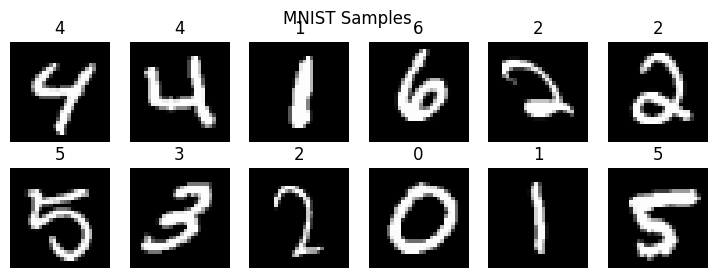

In [11]:
# Grab one batch
images, labels = next(iter(train_ds))
print('Batch images:', images.shape, '| labels:', labels[:12].numpy().tolist())
print('Pixel range (after normalize):', float(tf.reduce_min(images)), 'to', float(tf.reduce_max(images)))

fig = plt.figure(figsize=(9, 3))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.imshow(tf.squeeze(images[i], axis=-1), cmap='gray')
    ax.set_title(int(labels[i]))
    ax.axis('off')
plt.suptitle('MNIST Samples')
plt.show()


In [ ]:
def build_mlp():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Flatten()(inputs)  
    x = layers.Dense(256, activation='relu')(x) # simple linear layer.
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    logits = layers.Dense(10)(x) 
    return keras.Model(inputs, logits, name='mlp_mnist')


model = build_mlp()
model.summary()

# Sanity-check shapes on one mini-batch
logits0 = model(images)
print('Input batch:', images.shape, '| Logits:', logits0.shape)

Model: "mlp_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Input batch: (64, 28, 28, 1) | Logits: (64, 10)


In [24]:
model = build_mlp()
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='acc')]
)

EPOCHS = 30

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1
)


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.4798 - loss: 1.5889 - val_acc: 0.7052 - val_loss: 0.9571
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.7655 - loss: 0.7726 - val_acc: 0.8154 - val_loss: 0.6186
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.8313 - loss: 0.5672 - val_acc: 0.8496 - val_loss: 0.5080
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.8556 - loss: 0.4858 - val_acc: 0.8668 - val_loss: 0.4511
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.8695 - loss: 0.4426 - val_acc: 0.8779 - val_loss: 0.4184
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - acc: 0.8778 - loss: 0.4151 - val_acc: 0.8823 - val_loss: 0.3969
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8839 - loss: 0.3960 - val_acc: 0.8902 - val_loss: 0.3788
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8888 - loss: 0.3818 - val_acc: 0.8929 - val_loss: 0.3675
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - ac

In [25]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [26]:
predictions[0]

array([-0.7574225 , -5.0233574 ,  0.78698367,  5.1909747 , -3.5609252 ,
        0.603301  , -9.922819  , 11.116627  , -1.6923897 ,  2.7358263 ],
      dtype=float32)

In [27]:
arg_max = np.argmax(predictions, axis=1)
arg_max[0]

np.int64(7)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

confusion_matrix(y_test, arg_max)

array([[ 957,    0,    2,    1,    0,    6,    6,    4,    2,    2],
       [   0, 1095,    3,    3,    1,    5,    4,    2,   22,    0],
       [  12,   10,  902,   14,   15,    5,   15,   11,   42,    6],
       [   4,    1,   26,  892,    0,   44,    2,   14,   16,   11],
       [   2,    4,    3,    2,  905,    2,   18,    3,    9,   34],
       [   8,    3,    4,   34,   10,  767,   20,    9,   30,    7],
       [  13,    3,    5,    1,   10,   15,  904,    4,    3,    0],
       [   4,   10,   28,    5,   11,    0,    0,  932,    2,   36],
       [  10,    6,    5,   26,   10,   30,   16,    7,  853,   11],
       [  12,    6,    2,    9,   44,    7,    0,   28,    9,  892]])

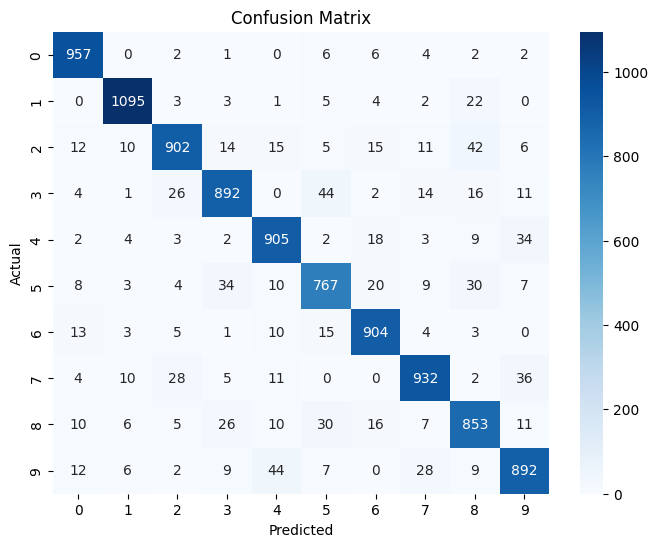

In [29]:
# plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, arg_max), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
import numpy as np
import pandas as pd

# Dataset 1: Smaller scale
true_1 = np.array([10, 20, 30, 40, 50])
pred_1 = np.array([12, 18, 29, 42, 48])


# Dataset 2: Larger scale (same proportional differences as Dataset 1)
true_2 = true_1 * 100  # Scale up by a factor of 100
pred_2 = pred_1 * 100  # Predictions scaled similarly

# Combine into a DataFrame for easier visualization
data = {
    "True_1": true_1,
    "Pred_1": pred_1,
    "True_2": true_2,
    "Pred_2": pred_2,
}
df = pd.DataFrame(data)
df

,True_1,Pred_1,True_2,Pred_2
0,10,12,1000,1200
1,20,18,2000,1800
2,30,29,3000,2900
3,40,42,4000,4200
4,50,48,5000,4800


In [31]:
def calculate_metrics(true, pred):
  mae = np.mean(np.abs(true - pred))
  mse = np.mean((true - pred)**2)

  mape = np.mean(np.abs((true - pred)/true))* 100

  return mae, mse, mape

In [32]:

# Metrics for Dataset 1
mae_1, mse_1, mape_1 = calculate_metrics(true_1, pred_1)

# Metrics for Dataset 2
mae_2, mse_2, mape_2 = calculate_metrics(true_2, pred_2)

# Display the metrics
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "MAPE"],
    "Dataset 1": [mae_1, mse_1, mape_1],
    "Dataset 2": [mae_2, mse_2, mape_2],
})

# Display the DataFrame and the metrics
print("Data:")
display(df)
print("\nMetrics Comparison:")
display(metrics)

Data:


,True_1,Pred_1,True_2,Pred_2
0,10,12,1000,1200
1,20,18,2000,1800
2,30,29,3000,2900
3,40,42,4000,4200
4,50,48,5000,4800



Metrics Comparison:


,Metric,Dataset 1,Dataset 2
0,MAE,1.800000,180.000000
1,MSE,3.400000,34000.000000
2,MAPE,8.466667,8.466667


on average your prediction is about 8.46% away from the actual value. 

for Regression metrics can be, R2 Score